In [3]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Common period of all datasets

In [4]:
iyear = 1981
fyear = 2015

# Datasets used

In [5]:
models = ['APHRO','CHIRPS','CRU','ERA5','GPCP','HARv2']

# Annual Time series for precipitation datasets (Appendix 4)

Annual mean (temporally and spatially) is computed for every year available for the different datasets. For more details : '/home/bricej/MyPythonLibrary/StageM2_IVT/script/compute_timeseries_tp_{model}'

In [6]:
tp_datasets = {} # dictionnary to store precipitation time series

domain = 'HMA' # for all High Mountain Asia (HMA) (see definition in '/home/bricej/MyPythonLibrary/StageM2_IVT/library/domain.py')

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

# APHRO
model=models[0]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1951-2015_{model}.csv')

# GPCP
model=models[4]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1891-2019_{model}.csv')

# CRU
model=models[2]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1901-2020_{model}.csv')

# CHIRPS
model=models[1]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1981-2024_{model}.csv')

# HARv2
model=models[5]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1980-2023_{model}.csv')

# ERA5
model=models[3]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1940-2025_{model}.csv')

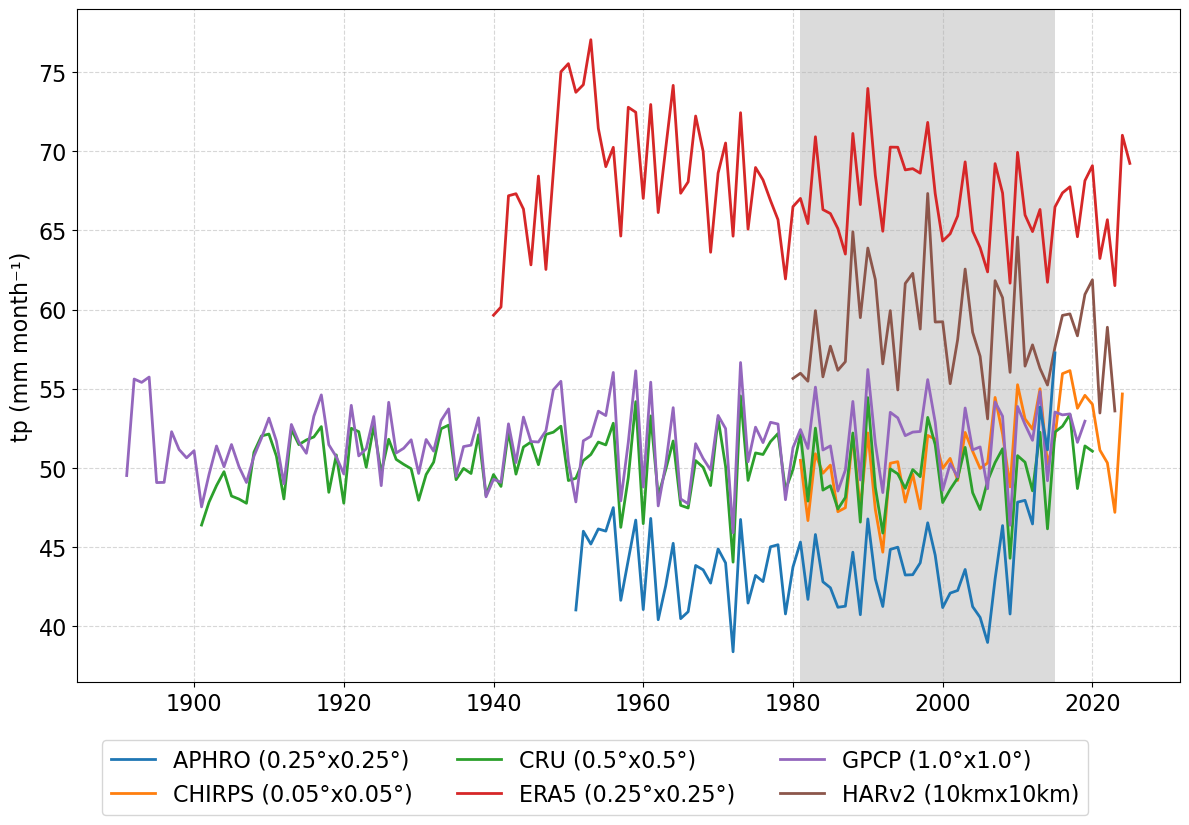

In [8]:
# spatial resolution for every dataset for the legend
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

# domain
dom='HMA'

# ====================== plot time series ========================

# figure
fig, ax = plt.subplots(figsize=(12,8))

for model in models:
    da = tp_datasets[model][dom]

    # to make every line really seen
    if model == 'APHRO':
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=2, zorder=10)
    else:
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=2, zorder=2)

ax.set_ylabel('tp (mm month⁻¹)', fontsize=16)
ax.tick_params(labelbottom=True, labelsize=16)
ax.grid(True, linestyle='--', alpha=0.5)

# common period for al datasets : 1981-2015
ax.axvspan(1981,2015,color='lightgray',alpha=0.8,zorder=0,ec=None)

# legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(0.5, -0.04),ncol=3,fontsize=16,frameon=True)

plt.tight_layout(rect=[0,0.08,1,1]) # [left, bottom, right, top]
plt.show()

# Statistics on the common period 1981-2015 (gray shaded area) relative to ERA5

Table 2. Performance statistics of precipitation datasets relative to ERA5 for the common period 1981–2015 in HMA : the analysis is based on the annual time series of precipitation datasets (see Table 1) over 1981-2015 (Fig. A4). Correlation coefficient values correspond to the Pearson correlation coefficient taking ERA5 as a reference. Root Mean Square Error (RMSE, mm.month-1). The third column represents the mean bias in mm.month-1.

## Pearson Correlation

In [18]:
# taking only the common period 
for model in models:
    tp_datasets[model]['HMA'] = tp_datasets[model]['HMA'][tp_datasets[model]['HMA']['year'].between(1981, 2015)].reset_index(drop=True)

In [14]:
# table to store pearson correlation coefficients
coherence = pd.DataFrame(index=['APHRO', 'GPCP', 'CRU', 'CHIRPS', 'HARv2'], columns=['coherence'], dtype=float)

# référence
ref_model = 'ERA5'
ref_df = tp_datasets[ref_model][domain][['year', 'tp']]

for model in ['APHRO', 'GPCP', 'CRU', 'CHIRPS', 'HARv2']:
    df = tp_datasets[model][domain][['year', 'tp']]
    merged = pd.merge(ref_df,df,on='year',suffixes=('_ref', '_model')).dropna() # merge sur les années communes and drop NaN
    
    # corrélation (Pearson)
    corr = merged['tp_ref'].corr(merged['tp_model'])

    coherence.loc[model, 'coherence'] = corr

display(coherence.style.format("{:.2f}"))

,coherence
APHRO,0.24
GPCP,0.84
CRU,0.75
CHIRPS,0.33
HARv2,0.76


## RMSE

In [16]:
era5 = tp_datasets['ERA5']['HMA'][['year', 'tp']] # reference
rmse = pd.DataFrame(index=['APHRO', 'GPCP', 'CRU', 'CHIRPS', 'HARv2'], columns=['rmse'], dtype=float) # table to store RMSE values

for model in ['APHRO', 'GPCP', 'CRU', 'CHIRPS', 'HARv2']:
    df = tp_datasets[model]['HMA'][['year', 'tp']]

    diff = (df['tp'] - era5['tp'])**2 # différence au carré pour chaque année
    sum_diff = np.sum(diff) # la somme de ces différences
    rmse_model = np.sqrt(sum_diff/35) # diviser par le nombre total d'année (1981-2015)

    rmse.loc[model,'rmse'] = rmse_model

display(rmse.style.format("{:.2f}"))

,rmse
APHRO,23.05
GPCP,15.27
CRU,17.58
CHIRPS,16.94
HARv2,8.45


## Mean Bias

In [19]:
era5 = tp_datasets['ERA5']['HMA'][['year', 'tp']]
bias = pd.DataFrame(index=['APHRO', 'GPCP', 'CRU', 'CHIRPS', 'HARv2'], columns=['bias'], dtype=float) # table to store bias values

for model in ['APHRO', 'GPCP', 'CRU', 'CHIRPS', 'HARv2']:
    df = tp_datasets[model]['HMA'][['year', 'tp']]

    diff = df['tp'] - era5['tp'] # différence pour chaque année
    mean_diff = np.mean(diff) # moyenne des ces différences pour la période 1981-2015

    bias.loc[model,'bias'] = mean_diff

display(bias.style.format("{:.2f}"))

,bias
APHRO,-22.66
GPCP,-15.19
CRU,-17.48
CHIRPS,-16.66
HARv2,-8.18
